# MSCS 634 – Data Mining

## Lab 1: Data Visualization, Preprocessing, and Statistical Analysis

**Student Name:** Priya Thapa

**Dataset:** USA House Prices Dataset

**Source:** Kaggle

**Dataset Link:** https://www.kaggle.com/datasets/fratzcan/usa-house-prices


## Step 1: Data Collection

For this lab, the USA House Prices dataset was selected from Kaggle. The dataset contains information about residential properties in the United States, including house prices, number of bedrooms and bathrooms, living area, lot size, number of floors, property condition, construction year, renovation year, city, and location.

This dataset is appropriate for the lab because it includes both numerical and categorical variables. The numerical attributes can be used for statistical analysis, scaling, outlier detection, and visualizations, while the categorical attributes can be used to compare housing characteristics across different cities and property groups.

The dataset will be loaded into a Pandas DataFrame so that its structure and contents can be inspected and analyzed.



In [ ]:
from google.colab import files

uploaded = files.upload()



Saving USA Housing Dataset.csv to USA Housing Dataset (2).csv


## Step 1: Data Collection

For this lab, the USA House Prices dataset was selected from Kaggle. The dataset contains housing-related information such as price, number of bedrooms and bathrooms, living area, lot size, number of floors, property condition, construction year, and location.

This dataset is appropriate for the lab because it includes both numerical and categorical variables. These features can be used for data visualization, preprocessing, outlier detection, scaling, discretization, and statistical analysis.

The dataset is loaded into a Pandas DataFrame, and the first five rows are displayed to inspect its structure and confirm that the data was imported successfully.

In [ ]:
import pandas as pd

df = pd.read_csv("USA Housing Dataset.csv")

df.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-09 00:00:00,376000.0,3.0,2.00,1340,1384,3.0,0,0,3,1340,0,2008,0,9245-9249 Fremont Ave N,Seattle,WA 98103,USA
1,2014-05-09 00:00:00,800000.0,4.0,3.25,3540,159430,2.0,0,0,3,3540,0,2007,0,33001 NE 24th St,Carnation,WA 98014,USA
2,2014-05-09 00:00:00,2238888.0,5.0,6.50,7270,130017,2.0,0,0,3,6420,850,2010,0,7070 270th Pl SE,Issaquah,WA 98029,USA
3,2014-05-09 00:00:00,324000.0,3.0,2.25,998,904,2.0,0,0,3,798,200,2007,0,820 NW 95th St,Seattle,WA 98117,USA
4,2014-05-10 00:00:00,549900.0,5.0,2.75,3060,7015,1.0,0,0,5,1600,1460,1979,0,10834 31st Ave SW,Seattle,WA 98146,USA


## Step 2: Data Visualization

Data visualization is an essential part of exploratory data analysis because it helps reveal patterns, relationships, trends, and potential anomalies within the dataset. In this section, various visualization techniques are used to better understand the characteristics of the USA House Prices dataset. These visualizations provide valuable insights that will support the preprocessing and statistical analysis performed in later steps.

### Importing Visualization Libraries

The Matplotlib and Seaborn libraries are imported to create informative charts and graphs. These libraries provide a variety of visualization tools that help summarize and interpret the housing data.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean plotting style
sns.set_style("whitegrid")

### Scatter Plot: Living Area vs. House Price

A scatter plot is used to examine the relationship between a home's living area and its selling price. This visualization helps determine whether larger homes generally have higher market values.

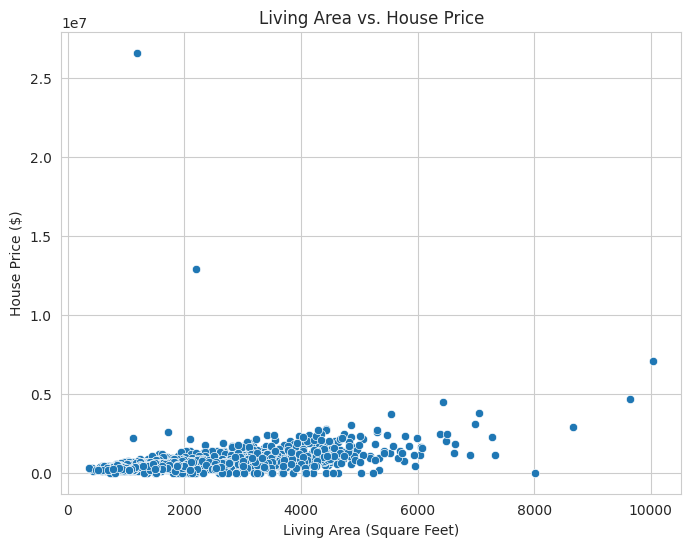

In [ ]:
plt.figure(figsize=(8,6))

sns.scatterplot(data=df, x="sqft_living", y="price")

plt.title("Living Area vs. House Price")
plt.xlabel("Living Area (Square Feet)")
plt.ylabel("House Price ($)")

plt.show()

**Insight:** The scatter plot shows a positive relationship between living area and house price. As the living area increases, the selling price generally tends to increase as well, although some high-priced outliers are present.

### Histogram: Distribution of House Prices

A histogram displays the frequency distribution of house prices. This helps determine whether the prices are evenly distributed or skewed toward a particular price range.

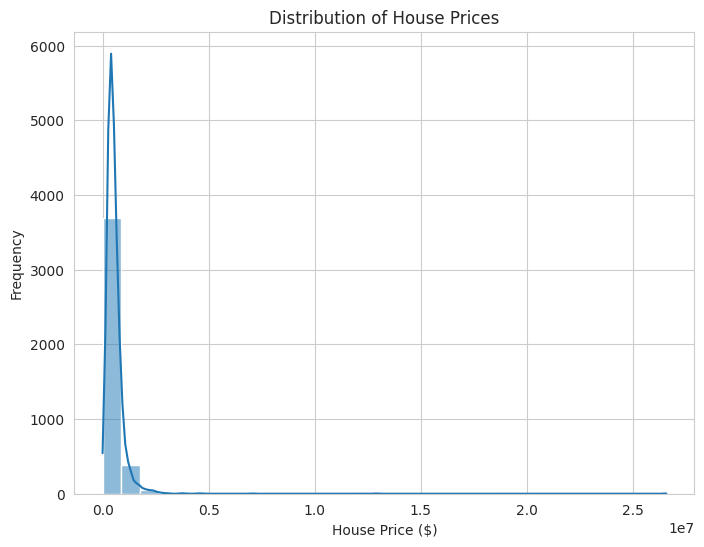

In [ ]:
plt.figure(figsize=(8,6))

sns.histplot(df["price"], bins=30, kde=True)

plt.title("Distribution of House Prices")
plt.xlabel("House Price ($)")
plt.ylabel("Frequency")

plt.show()

**Insight:** The histogram indicates that most homes fall within the lower and middle price ranges, while a smaller number of expensive homes create a right-skewed distribution.

### Box Plot: House Prices

A box plot summarizes the distribution of house prices while highlighting potential outliers that may influence future statistical analysis.

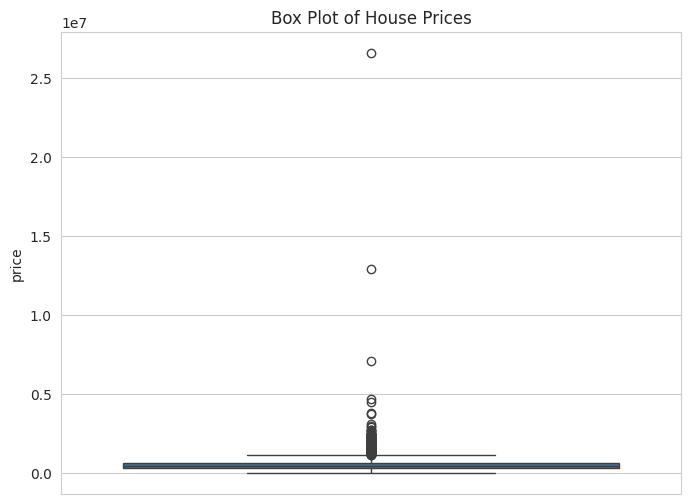

In [ ]:
plt.figure(figsize=(8,6))

sns.boxplot(y=df["price"])

plt.title("Box Plot of House Prices")

plt.show()

**Insight:** Several properties have prices significantly higher than the majority of the dataset, indicating the presence of outliers.

### Bar Chart: Average House Price by Number of Floors

A bar chart compares the average selling price of houses with different numbers of floors.

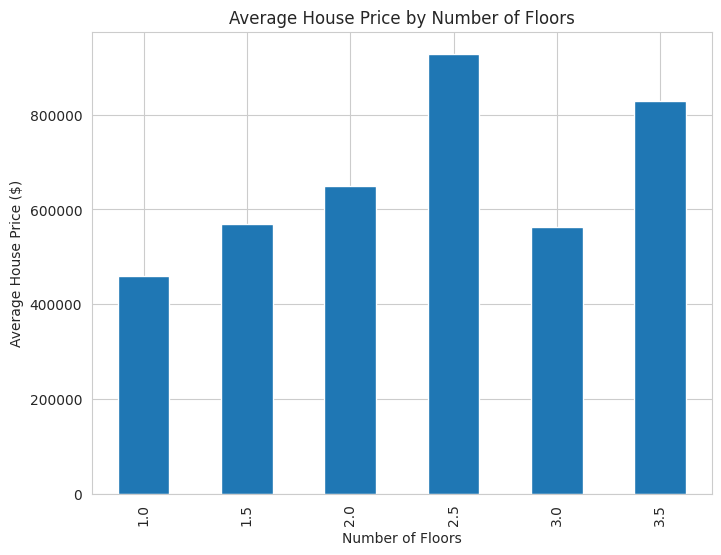

In [ ]:
avg_price = df.groupby("floors")["price"].mean()

plt.figure(figsize=(8,6))

avg_price.plot(kind="bar")

plt.title("Average House Price by Number of Floors")
plt.xlabel("Number of Floors")
plt.ylabel("Average House Price ($)")

plt.show()

**Insight:** Houses with different numbers of floors have varying average prices, suggesting that the number of floors may influence a property's market value.

### Pie Chart: Waterfront Properties

The pie chart illustrates the proportion of houses with and without waterfront access.

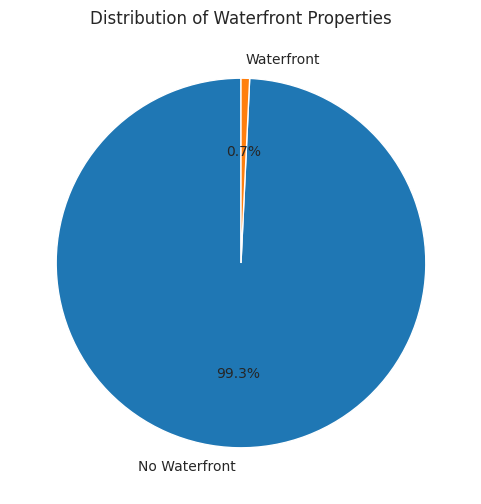

In [ ]:
waterfront_counts = df["waterfront"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    waterfront_counts,
    labels=["No Waterfront", "Waterfront"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Distribution of Waterfront Properties")

plt.show()

**Insight:** The majority of houses in the dataset do not have waterfront access, while waterfront properties represent only a small percentage of all homes.

### Line Plot: Average House Price by Year Built

The line plot shows how the average selling price changes based on the year in which the house was built.

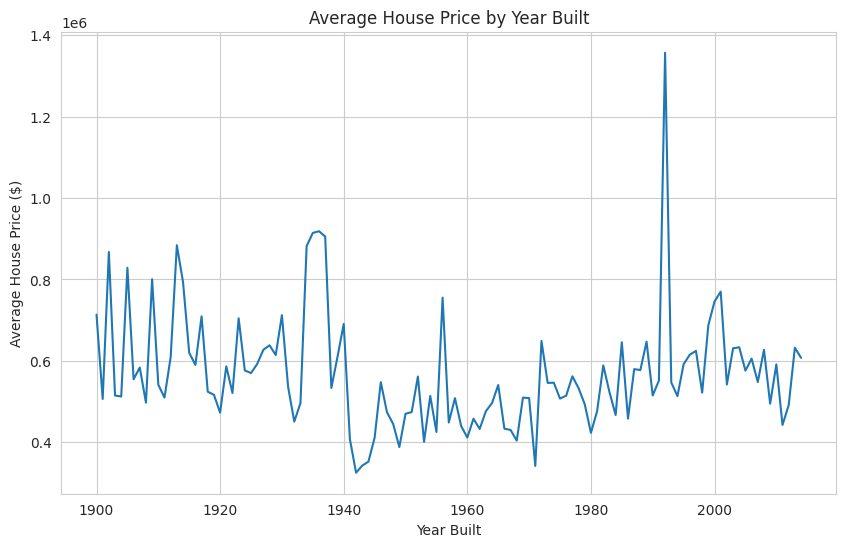

In [ ]:
year_price = df.groupby("yr_built")["price"].mean()

plt.figure(figsize=(10,6))

plt.plot(year_price.index, year_price.values)

plt.title("Average House Price by Year Built")
plt.xlabel("Year Built")
plt.ylabel("Average House Price ($)")

plt.show()

**Insight:** Average house prices vary across construction years. In general, newer homes tend to have higher average prices than older homes, although some fluctuations are observed.

## Step 3: Data Preprocessing

Data preprocessing is an important step in the data analysis process because it improves the quality and reliability of the dataset before performing statistical analysis or building predictive models. In this section, the dataset is examined for missing values, outliers, unnecessary features, and differences in scale. Appropriate preprocessing techniques are then applied to prepare the data for further analysis.

### Handling Missing Values

Missing values can reduce the quality of a dataset and affect the accuracy of analysis. Before performing any preprocessing, the dataset is examined to identify columns containing missing values. Appropriate techniques, such as replacing missing values or removing incomplete records, can then be applied if necessary.

In [ ]:
# Check for missing values in each column
missing_values = df.isnull().sum()

missing_values

,0
date,0
price,0
bedrooms,0
bathrooms,0
sqft_living,0
sqft_lot,0
floors,0
waterfront,0
view,0
condition,0


In [ ]:
missing_values[missing_values > 0]

,0


**Observation:** The dataset was checked for missing values using the `isnull().sum()` function. The results show that all columns contain zero missing values. Since the dataset is complete, no imputation or removal of records was required. Therefore, the dataset remains unchanged for the next preprocessing steps.

### Outlier Detection and Removal

Outliers are observations that differ significantly from the rest of the data. These extreme values can influence statistical analysis and predictive models. The Interquartile Range (IQR) method is used to identify potential outliers in the house prices. Records outside the acceptable range are then removed to create a cleaner dataset.

In [ ]:
# Calculate the first and third quartiles
Q1 = df["price"].quantile(0.25)
Q3 = df["price"].quantile(0.75)

# Calculate the Interquartile Range (IQR)
IQR = Q3 - Q1

# Determine the lower and upper bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Q1: 320000.0
Q3: 659125.0
IQR: 339125.0
Lower Bound: -188687.5
Upper Bound: 1167812.5


### Identify Outliers

After calculating the Interquartile Range (IQR), the lower and upper bounds are used to identify observations that fall outside the acceptable range. These observations are considered potential outliers and are displayed for inspection before being removed from the dataset.

In [ ]:
# Identify outliers
outliers = df[(df["price"] < lower_bound) | (df["price"] > upper_bound)]

print("Number of Outliers:", len(outliers))

# Display the first few outliers
outliers.head()

Number of Outliers: 215


,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
2,2014-05-09 00:00:00,2238888.0,5.0,6.50,7270,130017,2.0,0,0,3,6420,850,2010,0,7070 270th Pl SE,Issaquah,WA 98029,USA
11,2014-05-12 00:00:00,1225000.0,4.0,4.50,5420,101930,1.0,0,0,3,3890,1530,2001,0,25005 NE Patterson Way,Redmond,WA 98053,USA
18,2014-05-12 00:00:00,1200000.0,3.0,1.75,1560,8078,1.5,1,4,4,1560,0,1928,0,3603 W Mercer Way,Mercer Island,WA 98040,USA
22,2014-05-12 00:00:00,1575000.0,5.0,2.75,3650,20150,1.0,0,0,4,2360,1290,1975,0,1216 86th Ave NE,Bellevue,WA 98004,USA
28,2014-05-12 00:00:00,1315000.0,4.0,3.50,3460,3997,2.0,0,0,3,2560,900,2004,2003,2346 N 59th St,Seattle,WA 98103,USA


### Remove Outliers

The identified outliers are removed from the dataset using the IQR boundaries. Removing extreme values helps improve the quality of the dataset and reduces their influence on future statistical analysis and predictive modeling.

In [ ]:
# Remove outliers
df_clean = df[(df["price"] >= lower_bound) & (df["price"] <= upper_bound)]

print("Original Dataset Shape:", df.shape)
print("Dataset Shape After Removing Outliers:", df_clean.shape)

df_clean.head()

Original Dataset Shape: (4140, 18)
Dataset Shape After Removing Outliers: (3925, 18)


,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-09 00:00:00,376000.0,3.0,2.00,1340,1384,3.0,0,0,3,1340,0,2008,0,9245-9249 Fremont Ave N,Seattle,WA 98103,USA
1,2014-05-09 00:00:00,800000.0,4.0,3.25,3540,159430,2.0,0,0,3,3540,0,2007,0,33001 NE 24th St,Carnation,WA 98014,USA
3,2014-05-09 00:00:00,324000.0,3.0,2.25,998,904,2.0,0,0,3,798,200,2007,0,820 NW 95th St,Seattle,WA 98117,USA
4,2014-05-10 00:00:00,549900.0,5.0,2.75,3060,7015,1.0,0,0,5,1600,1460,1979,0,10834 31st Ave SW,Seattle,WA 98146,USA
5,2014-05-10 00:00:00,320000.0,3.0,2.50,2130,6969,2.0,0,0,3,2130,0,2003,0,Cedar to Green River Trail,Maple Valley,WA 98038,USA


### Visualizing before and after
The box plots below compare the distribution of house prices before and after removing outliers using the IQR method. The reduction in extreme values demonstrates the effectiveness of the preprocessing step.

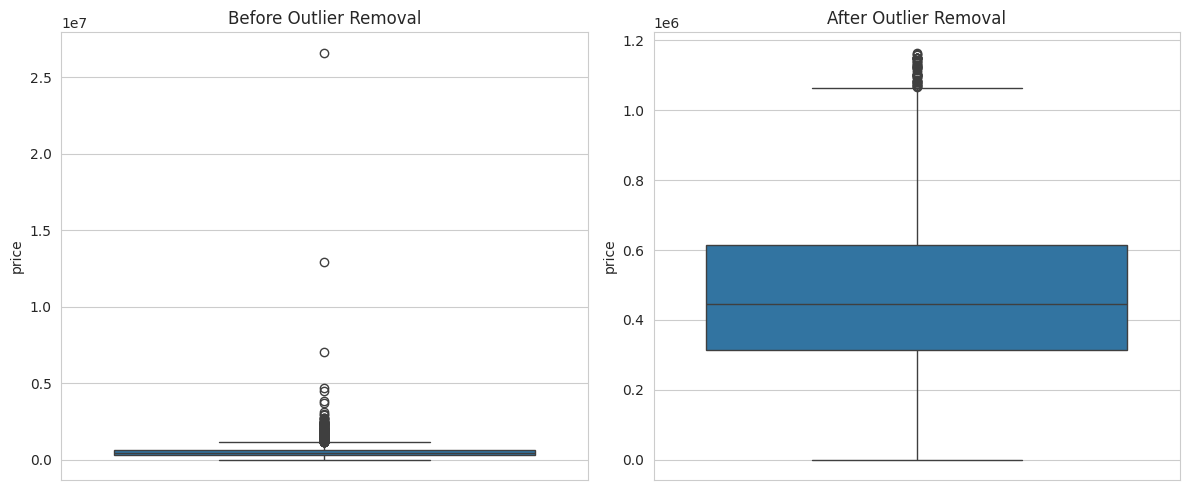

In [ ]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.boxplot(y=df["price"])
plt.title("Before Outlier Removal")

plt.subplot(1,2,2)
sns.boxplot(y=df_clean["price"])
plt.title("After Outlier Removal")

plt.tight_layout()
plt.show()

### Data Reduction

Data reduction simplifies the dataset while preserving important information. In this step, random sampling is used to reduce the number of records, and dimension elimination is performed by removing columns that are less relevant to the analysis. These techniques help improve efficiency while maintaining the overall characteristics of the data.

In [ ]:
# Randomly sample 50% of the cleaned dataset
df_sample = df_clean.sample(frac=0.5, random_state=42)

print("Original Dataset Shape:", df_clean.shape)
print("Sampled Dataset Shape:", df_sample.shape)

Original Dataset Shape: (3925, 18)
Sampled Dataset Shape: (1962, 18)


**Observation:** Data reduction was performed by randomly selecting 50% of the cleaned dataset and removing the `street` and `country` columns. Sampling reduced the number of records while preserving the overall distribution of the data. Removing less relevant columns simplified the dataset without affecting the key numerical and categorical variables needed for analysis.

In [ ]:
print("Original Dataset Shape:", df_clean.shape)
print("Sampled Dataset Shape:", df_sample.shape)

Original Dataset Shape: (3925, 18)
Sampled Dataset Shape: (1962, 18)


In [ ]:

df_reduced = df_sample.drop(columns=["street", "country"])

print("Dataset Shape After Removing Columns:", df_reduced.shape)

df_reduced.head()

Dataset Shape After Removing Columns: (1962, 16)


,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,city,statezip
3670,2014-07-08 00:00:00,530000.0,2.0,2.50,1785,779,2.0,0,0,3,1595,190,1975,0,Bellevue,WA 98004
486,2014-05-20 00:00:00,243000.0,2.0,1.00,1770,5522,1.5,0,0,4,960,810,1943,0,Seattle,WA 98178
4070,2014-06-24 00:00:00,362750.0,2.0,1.75,1240,3000,1.5,0,0,3,1240,0,1906,2014,Seattle,WA 98105
3802,2014-07-09 00:00:00,625000.0,3.0,1.75,3160,76230,1.0,0,0,4,2160,1000,1978,2000,Auburn,WA 98001
2199,2014-06-17 00:00:00,1010000.0,3.0,3.25,2420,1923,2.0,0,2,3,1840,580,2006,0,Seattle,WA 98109


### Data Scaling

Data scaling places numerical features on a common scale so that variables with large values do not dominate variables with smaller values. In this step, Min-Max Scaling is applied to selected numerical columns. The transformed values will range from 0 to 1.

In [ ]:
from sklearn.preprocessing import MinMaxScaler

# Create a copy of the reduced dataset
df_scaled = df_reduced.copy()

# Select numerical columns to scale
columns_to_scale = [
    "price",
    "bedrooms",
    "bathrooms",
    "sqft_living",
    "sqft_lot",
    "floors"
]

# Display the selected columns before scaling
print("Before Scaling:")
display(df_scaled[columns_to_scale].head())

# Create and apply the Min-Max Scaler
scaler = MinMaxScaler()
df_scaled[columns_to_scale] = scaler.fit_transform(
    df_scaled[columns_to_scale]
)

# Display the selected columns after scaling
print("After Scaling:")
display(df_scaled[columns_to_scale].head())

Before Scaling:


,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors
3670,530000.0,2.0,2.50,1785,779,2.0
486,243000.0,2.0,1.00,1770,5522,1.5
4070,362750.0,2.0,1.75,1240,3000,1.5
3802,625000.0,3.0,1.75,3160,76230,1.0
2199,1010000.0,3.0,3.25,2420,1923,2.0


After Scaling:


,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors
3670,0.460870,0.166667,0.318182,0.183901,0.000333,0.50
486,0.211304,0.166667,0.045455,0.181937,0.011541,0.25
4070,0.315435,0.166667,0.181818,0.112565,0.005581,0.25
3802,0.543478,0.333333,0.181818,0.363874,0.178620,0.00
2199,0.878261,0.333333,0.454545,0.267016,0.003036,0.50


**Observation:** Min-Max Scaling transformed the selected numerical features into values between 0 and 1. The relative differences among the observations were preserved, but the variables are now expressed on a consistent scale.

### Data Discretization

Data discretization transforms continuous numerical values into categorical groups. This technique simplifies analysis by grouping similar values together. In this step, house prices are categorized into three levels: Low, Medium, and High based on their distribution.

In [ ]:
# Create a copy of the scaled dataset
df_discretized = df_scaled.copy()

# Divide house prices into three categories
df_discretized["price_category"] = pd.qcut(
    df_discretized["price"],
    q=3,
    labels=["Low", "Medium", "High"]
)

# Display the first five rows
df_discretized[["price", "price_category"]].head()

,price,price_category
3670,0.460870,Medium
486,0.211304,Low
4070,0.315435,Medium
3802,0.543478,High
2199,0.878261,High


In [ ]:
# Display the number of houses in each category
df_discretized["price_category"].value_counts()

,count
price_category,
Low,654
Medium,654
High,654


**Observation:** The continuous house price variable was converted into three categories: Low, Medium, and High. Discretization simplifies the numerical data into meaningful groups, making it easier to compare houses based on their price range and supporting future classification tasks.

## Step 4: Statistical Analysis

Statistical analysis provides a quantitative summary of the dataset by describing its central tendency, variability, and relationships among variables. In this section, descriptive statistics and correlation analysis are performed to better understand the characteristics of the USA House Prices dataset.

### General Overview of the Dataset

The `info()` and `describe()` functions provide an overview of the dataset. The `info()` function summarizes the data types and number of non-null values, while `describe()` calculates descriptive statistics for the numerical variables.

In [56]:
# Display dataset information
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3925 entries, 0 to 4139
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           3925 non-null   object 
 1   price          3925 non-null   float64
 2   bedrooms       3925 non-null   float64
 3   bathrooms      3925 non-null   float64
 4   sqft_living    3925 non-null   int64  
 5   sqft_lot       3925 non-null   int64  
 6   floors         3925 non-null   float64
 7   waterfront     3925 non-null   int64  
 8   view           3925 non-null   int64  
 9   condition      3925 non-null   int64  
 10  sqft_above     3925 non-null   int64  
 11  sqft_basement  3925 non-null   int64  
 12  yr_built       3925 non-null   int64  
 13  yr_renovated   3925 non-null   int64  
 14  street         3925 non-null   object 
 15  city           3925 non-null   object 
 16  statezip       3925 non-null   object 
 17  country        3925 non-null   object 
dtypes: float64(4)

In [57]:
# Display descriptive statistics
df_clean.describe()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated
count,3.925000e+03,3925.000000,3925.000000,3925.000000,3.925000e+03,3925.000000,3925.000000,3925.000000,3925.000000,3925.000000,3925.000000,3925.000000,3925.00000
mean,4.820708e+05,3.360255,2.104713,2045.507771,1.448322e+04,1.498089,0.004586,0.185987,3.448662,1758.575287,286.932484,1970.840255,810.46879
std,2.233401e+05,0.885176,0.730587,829.348265,3.626443e+04,0.533471,0.067573,0.676576,0.674062,779.237470,428.058294,29.589792,979.78562
min,0.000000e+00,0.000000,0.000000,370.000000,6.380000e+02,1.000000,0.000000,0.000000,1.000000,370.000000,0.000000,1900.000000,0.00000
25%,3.145000e+05,3.000000,1.750000,1440.000000,5.000000e+03,1.000000,0.000000,0.000000,3.000000,1170.000000,0.000000,1951.000000,0.00000
50%,4.450000e+05,3.000000,2.250000,1930.000000,7.563000e+03,1.500000,0.000000,0.000000,3.000000,1550.000000,0.000000,1975.000000,0.00000
75%,6.150000e+05,4.000000,2.500000,2530.000000,1.068800e+04,2.000000,0.000000,0.000000,4.000000,2210.000000,570.000000,1997.000000,1999.00000
max,1.165000e+06,8.000000,6.250000,8020.000000,1.074218e+06,3.500000,1.000000,4.000000,5.000000,8020.000000,2300.000000,2014.000000,2014.00000


### Central Tendency Measures

Measures of central tendency describe the typical or average values within the dataset. The minimum, maximum, mean, median, and mode are calculated for the house price variable.

In [58]:
price = df_clean["price"]

print("Minimum Price:", price.min())
print("Maximum Price:", price.max())
print("Mean Price:", price.mean())
print("Median Price:", price.median())
print("Mode Price:")
print(price.mode())

Minimum Price: 0.0
Maximum Price: 1165000.0
Mean Price: 482070.79467773886
Median Price: 445000.0
Mode Price:
0    0.0
Name: price, dtype: float64


**Observation:** The mean, median, and mode summarize the central location of house prices, while the minimum and maximum values indicate the overall price range within the cleaned dataset.

### Dispersion Measures

Dispersion measures describe how spread out the house prices are within the dataset. These statistics provide insight into the variability of the data.

In [59]:
# Calculate quartiles
Q1 = price.quantile(0.25)
Q3 = price.quantile(0.75)

# Calculate IQR
IQR = Q3 - Q1

# Calculate range
price_range = price.max() - price.min()

print("Range:", price_range)
print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Variance:", price.var())
print("Standard Deviation:", price.std())

Range: 1165000.0
Q1: 314500.0
Q3: 615000.0
IQR: 300500.0
Variance: 49880800694.8268
Standard Deviation: 223340.10095553103


**Observation:** The range, quartiles, and interquartile range describe the spread of house prices, while the variance and standard deviation quantify the overall variability within the cleaned dataset.

### Correlation Analysis

A correlation matrix measures the strength and direction of relationships between numerical variables. Positive values indicate a direct relationship, while negative values indicate an inverse relationship.

In [60]:
# Compute the correlation matrix
correlation_matrix = df_clean.corr(numeric_only=True)

correlation_matrix

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated
price,1.000000,0.277817,0.438728,0.577487,0.092390,0.268396,0.037584,0.186132,0.040959,0.499301,0.209934,0.064141,-0.070864
bedrooms,0.277817,1.000000,0.520635,0.592306,0.059634,0.160122,-0.027628,0.055750,0.014347,0.462155,0.306266,0.162329,-0.072770
bathrooms,0.438728,0.520635,1.000000,0.734121,0.086444,0.492057,0.038020,0.134206,-0.139541,0.654786,0.230361,0.517851,-0.241313
sqft_living,0.577487,0.592306,0.734121,1.000000,0.195633,0.339687,0.054022,0.208618,-0.083553,0.860178,0.371598,0.337209,-0.141401
sqft_lot,0.092390,0.059634,0.086444,0.195633,1.000000,-0.003022,0.025097,0.082297,0.016946,0.192875,0.027921,0.039895,-0.015706
floors,0.268396,0.160122,0.492057,0.339687,-0.003022,1.000000,0.010847,-0.008900,-0.292433,0.530967,-0.308440,0.499686,-0.242239
waterfront,0.037584,-0.027628,0.038020,0.054022,0.025097,0.010847,1.000000,0.326938,0.016360,0.030441,0.049252,-0.028693,0.005306
view,0.186132,0.055750,0.134206,0.208618,0.082297,-0.008900,0.326938,1.000000,0.048882,0.087711,0.244520,-0.064938,0.040932
condition,0.040959,0.014347,-0.139541,-0.083553,0.016946,-0.292433,0.016360,0.048882,1.000000,-0.204301,0.210029,-0.401424,-0.186665
sqft_above,0.499301,0.462155,0.654786,0.860178,0.192875,0.530967,0.030441,0.087711,-0.204301,1.000000,-0.153835,0.455489,-0.175667


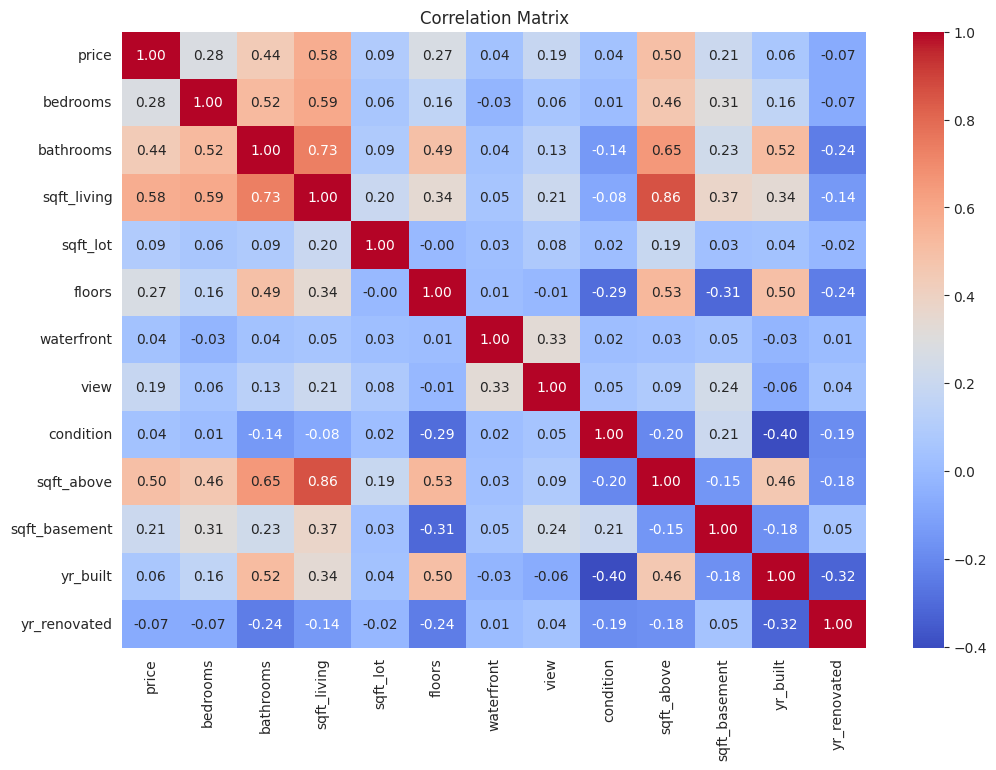

In [61]:
plt.figure(figsize=(12,8))

sns.heatmap(correlation_matrix,
            annot=True,
            cmap="coolwarm",
            fmt=".2f")

plt.title("Correlation Matrix")

plt.show()

**Observation:** The correlation matrix reveals the relationships among numerical variables. Features such as living area (`sqft_living`) and bathrooms generally show stronger positive correlations with house price, indicating that larger and better-equipped homes tend to have higher market values.